# CIND820 Milestone 2 — Exploratory Data Analysis
**Student:** Mubarak Ahmed (501345730)  
**Dataset:** USAID SCMS Delivery History Dataset  
**Purpose:** Data profiling, audit, and target variable engineering for shipment delay classification

In [13]:
# Section 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [14]:
# Section 2: Load Dataset
df = pd.read_csv('../data/raw/Suppy_Chain_Shipment_Data.csv', encoding='latin1')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (10324, 33)
Rows: 10324, Columns: 33

First 5 rows:


,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,CÃ´te d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,CÃ´te d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN


In [15]:
# Section 3: Data Types and Missing Values
print("=== Column Data Types ===")
print(df.dtypes)
print("\n=== Missing Values per Column ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Column Data Types ===
id                                int64
project code                     object
pq #                             object
po / so #                        object
asn/dn #                         object
country                          object
managed by                       object
fulfill via                      object
vendor inco term                 object
shipment mode                    object
pq first sent to client date     object
po sent to vendor date           object
scheduled delivery date          object
delivered to client date         object
delivery recorded date           object
product group                    object
sub classification               object
vendor                           object
item description                 object
molecule/test type               object
brand                            object
dosage                           object
dosage form                      object
unit of measure (per pack)        int64
line item quan

In [16]:
# Section 4: Create Target Variable (Delay Label)
# Parse date columns
df['scheduled delivery date'] = pd.to_datetime(df['scheduled delivery date'], errors='coerce')
df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')

# Calculate delay in days (positive = late, negative = early)
df['delay_days'] = (df['delivered to client date'] - df['scheduled delivery date']).dt.days

# Assign 3-class label
def label_delay(d):
    if pd.isna(d):
        return np.nan
    elif d <= 0:
        return 0   # on-time or early
    elif d <= 14:
        return 1   # at-risk
    else:
        return 2   # delayed

df['delay_label'] = df['delay_days'].apply(label_delay)

print("=== Target Variable Distribution ===")
counts = df['delay_label'].value_counts().sort_index()
labels = {0: 'On-time', 1: 'At-risk', 2: 'Delayed'}
for k, v in counts.items():
    print(f"{labels[k]} (class {int(k)}): {v} shipments ({v/len(df)*100:.1f}%)")

print(f"\nRecords dropped (missing dates): {df['delay_label'].isna().sum()}")

=== Target Variable Distribution ===
On-time (class 0): 9138 shipments (88.5%)
At-risk (class 1): 691 shipments (6.7%)
Delayed (class 2): 495 shipments (4.8%)

Records dropped (missing dates): 0


In [17]:
# Section 5: Descriptive Statistics
print("=== Descriptive Statistics for Numeric Columns ===")
df.describe().round(2)

=== Descriptive Statistics for Numeric Columns ===


,id,scheduled delivery date,delivered to client date,unit of measure (per pack),line item quantity,line item value,pack price,unit price,line item insurance (usd),delay_days,delay_label
count,10324.00,10324,10324,10324.00,10324.00,10324.00,10324.00,10324.00,10037.00,10324.00,10324.00
mean,51098.97,2011-10-04 15:30:28.593568256,2011-09-28 14:56:34.963192832,77.99,18332.53,157650.57,21.91,0.61,240.12,-6.02,0.16
min,1.00,2006-05-02 00:00:00,2006-05-02 00:00:00,1.00,1.00,0.00,0.00,0.00,0.00,-372.00,0.00
25%,12795.75,2009-09-08 00:00:00,2009-09-01 00:00:00,30.00,408.00,4314.59,4.12,0.08,6.51,-3.00,0.00
50%,57540.50,2011-12-05 00:00:00,2011-11-25 00:00:00,60.00,3000.00,30471.46,9.30,0.16,47.04,0.00,0.00
75%,83648.25,2013-12-23 00:00:00,2013-12-23 00:00:00,90.00,17039.75,166447.14,23.59,0.47,252.40,0.00,0.00
max,86823.00,2015-12-31 00:00:00,2015-09-14 00:00:00,1000.00,619999.00,5951990.40,1345.64,238.65,7708.44,192.00,2.00
std,31944.33,NaN,NaN,76.58,40035.30,345292.07,45.61,3.28,500.19,27.23,0.48


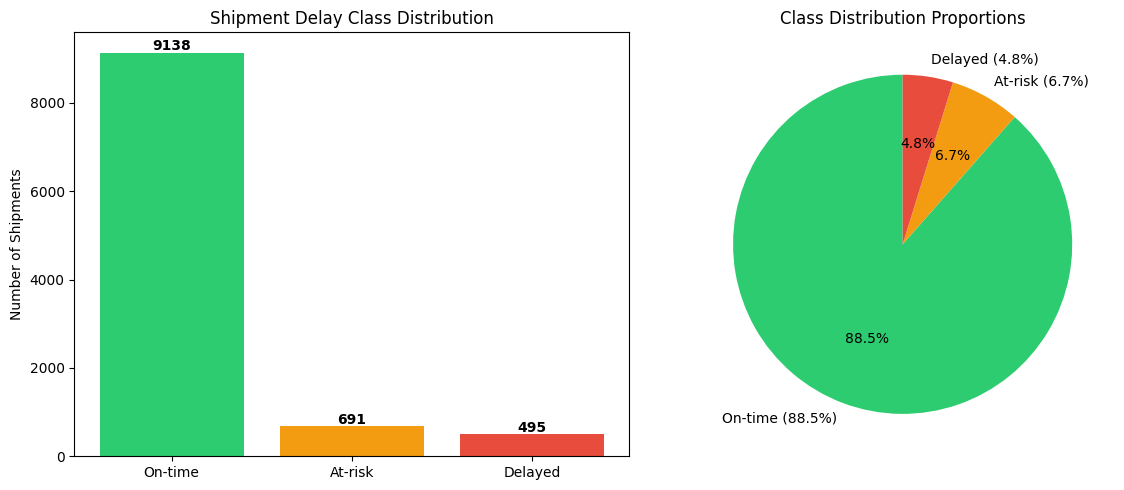

Figure saved to outputs/figures/


In [18]:
# Section 6: Target Variable Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(['On-time', 'At-risk', 'Delayed'], 
            [9138, 691, 495], color=colors)
axes[0].set_title('Shipment Delay Class Distribution')
axes[0].set_ylabel('Number of Shipments')
for i, v in enumerate([9138, 691, 495]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([9138, 691, 495], 
            labels=['On-time (88.5%)', 'At-risk (6.7%)', 'Delayed (4.8%)'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution Proportions')

plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/")

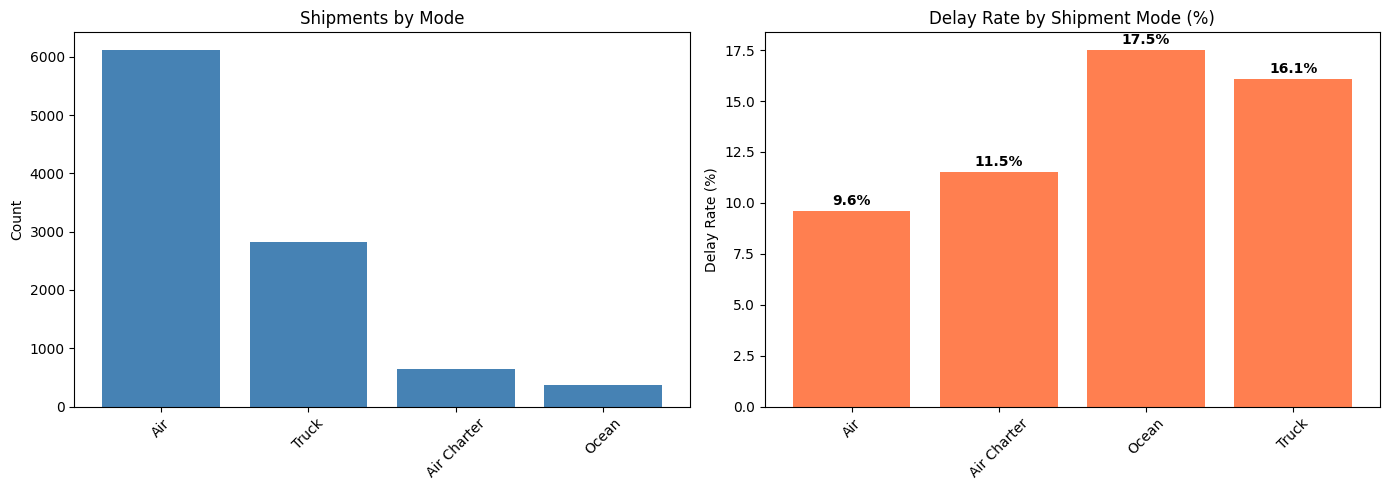

Figure saved!


In [19]:
# Section 7: Shipment Mode vs Delay Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shipment mode counts
mode_counts = df['shipment mode'].value_counts()
axes[0].bar(mode_counts.index, mode_counts.values, color='steelblue')
axes[0].set_title('Shipments by Mode')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Delay rate by shipment mode
mode_delay = df.groupby('shipment mode')['delay_label'].apply(
    lambda x: (x > 0).sum() / len(x) * 100
).round(1)
axes[1].bar(mode_delay.index, mode_delay.values, color='coral')
axes[1].set_title('Delay Rate by Shipment Mode (%)')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mode_delay.values):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/shipment_mode_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

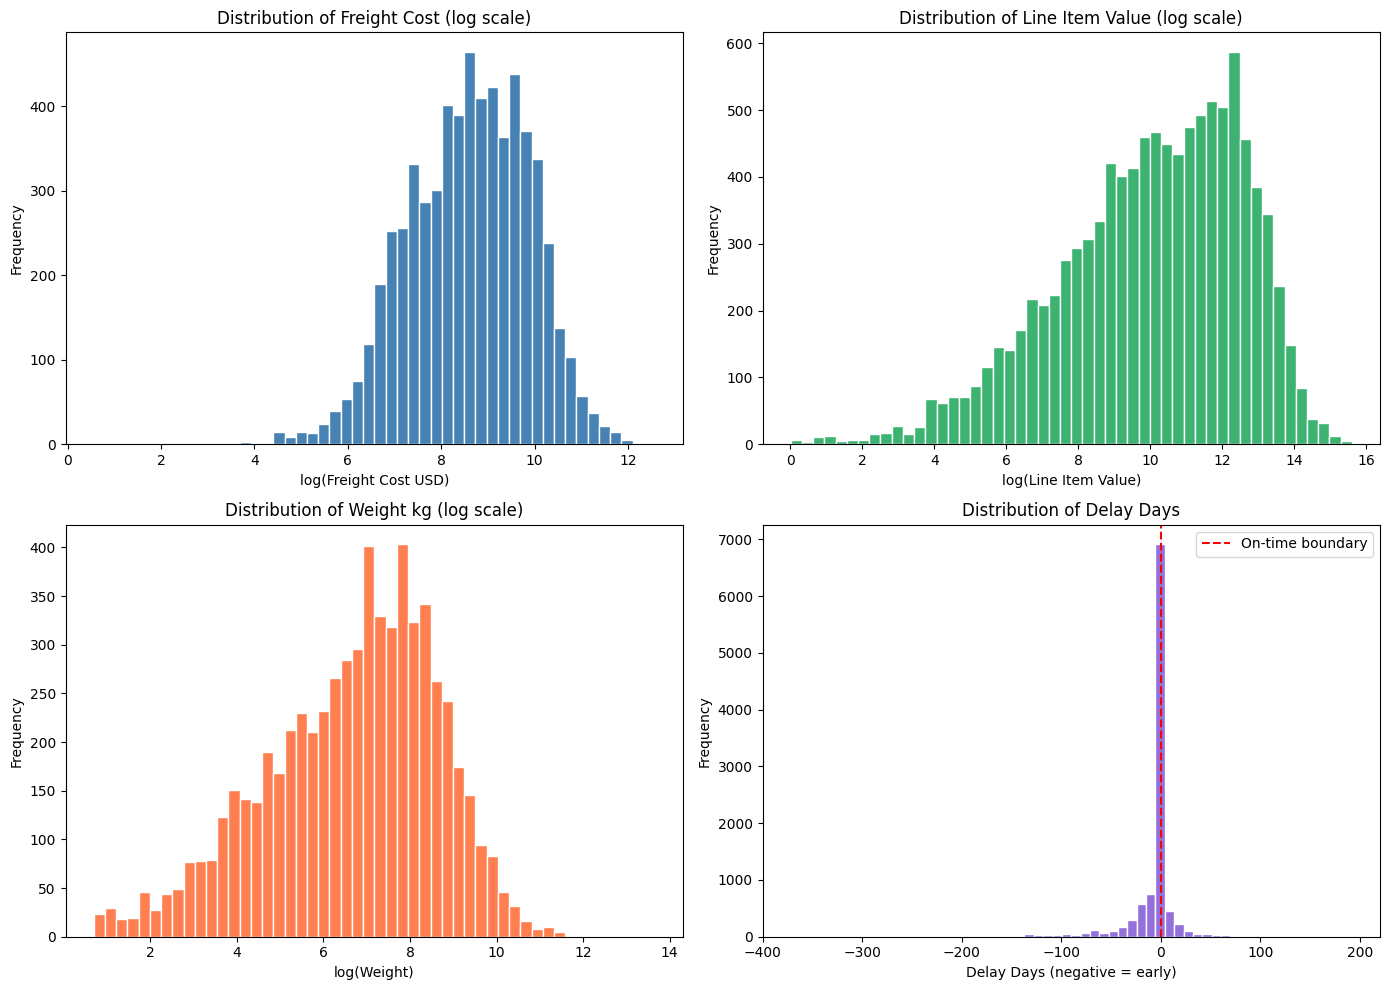

Figure saved!


In [20]:
# Section 8: Univariate Analysis - Numeric Predictors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Freight Cost distribution (log scale)
df['freight cost (usd)'] = pd.to_numeric(df['freight cost (usd)'], errors='coerce')
valid_freight = df['freight cost (usd)'].dropna()
valid_freight = valid_freight[valid_freight > 0]
axes[0,0].hist(np.log1p(valid_freight), bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Freight Cost (log scale)')
axes[0,0].set_xlabel('log(Freight Cost USD)')
axes[0,0].set_ylabel('Frequency')

# Line Item Value distribution (log scale)
valid_value = df['line item value'][df['line item value'] > 0]
axes[0,1].hist(np.log1p(valid_value), bins=50, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Distribution of Line Item Value (log scale)')
axes[0,1].set_xlabel('log(Line Item Value)')
axes[0,1].set_ylabel('Frequency')

# Weight distribution (log scale)
df['weight (kilograms)'] = pd.to_numeric(df['weight (kilograms)'], errors='coerce')
valid_weight = df['weight (kilograms)'].dropna()
valid_weight = valid_weight[valid_weight > 0]
axes[1,0].hist(np.log1p(valid_weight), bins=50, color='coral', edgecolor='white')
axes[1,0].set_title('Distribution of Weight kg (log scale)')
axes[1,0].set_xlabel('log(Weight)')
axes[1,0].set_ylabel('Frequency')

# Delay days distribution
valid_delay = df['delay_days'].dropna()
axes[1,1].hist(valid_delay, bins=60, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Distribution of Delay Days')
axes[1,1].set_xlabel('Delay Days (negative = early)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(x=0, color='red', linestyle='--', label='On-time boundary')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/univariate_numeric.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

In [21]:
# Section 9: Bivariate Analysis - Chi-squared Tests (Categorical vs Delay Label)
from scipy.stats import chi2_contingency

categorical_features = ['shipment mode', 'country', 'vendor', 'fulfill via', 'managed by']

print("=== Chi-squared Test: Categorical Features vs Delay Label ===")
print(f"{'Feature':<20} {'Chi2':>10} {'p-value':>12} {'Significant?':>14}")
print("-" * 60)

results = []
for col in categorical_features:
    temp = df[[col, 'delay_label']].dropna()
    ct = pd.crosstab(temp[col], temp['delay_label'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "YES ***" if p < 0.05 else "NO"
    print(f"{col:<20} {chi2:>10.2f} {p:>12.6f} {sig:>14}")
    results.append({'feature': col, 'chi2': chi2, 'p_value': p})

print("\nFeatures with p < 0.05 are statistically significant predictors of delay.")

=== Chi-squared Test: Categorical Features vs Delay Label ===
Feature                    Chi2      p-value   Significant?
------------------------------------------------------------
shipment mode            152.88     0.000000        YES ***
country                  553.15     0.000000        YES ***
vendor                   575.64     0.000000        YES ***
fulfill via              360.73     0.000000        YES ***
managed by                 5.71     0.456162             NO

Features with p < 0.05 are statistically significant predictors of delay.


In [22]:
# Section 10: Bivariate Analysis - Spearman Correlation (Numeric vs Delay Label)
from scipy.stats import spearmanr

numeric_features = ['freight cost (usd)', 'weight (kilograms)', 
                    'line item value', 'line item quantity']

print("=== Spearman Correlation: Numeric Features vs Delay Label ===")
print(f"{'Feature':<30} {'Correlation':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 72)

for col in numeric_features:
    temp = df[[col, 'delay_label']].dropna()
    temp = temp[pd.to_numeric(temp[col], errors='coerce').notna()]
    temp[col] = pd.to_numeric(temp[col], errors='coerce')
    corr, p = spearmanr(temp[col], temp['delay_label'])
    sig = "YES ***" if p < 0.05 else "NO"
    print(f"{col:<30} {corr:>12.4f} {p:>12.6f} {sig:>14}")

print("\nSpearman used (not Pearson) due to right-skewed distributions confirmed in Section 8.")

=== Spearman Correlation: Numeric Features vs Delay Label ===
Feature                         Correlation      p-value   Significant?
------------------------------------------------------------------------
freight cost (usd)                   0.0879     0.000000        YES ***
weight (kilograms)                   0.1355     0.000000        YES ***
line item value                      0.1077     0.000000        YES ***
line item quantity                   0.1486     0.000000        YES ***

Spearman used (not Pearson) due to right-skewed distributions confirmed in Section 8.


In [23]:
# Section 11: YData Profiling Report
from ydata_profiling import ProfileReport

print("Generating profiling report... this may take 2-3 minutes, please wait.")

profile = ProfileReport(
    df, 
    title="SCMS Shipment Dataset - Milestone 2 EDA Report",
    explorative=True,
    minimal=False
)

profile.to_file("../outputs/reports/M2_EDA_report.html")
print("Report saved to outputs/reports/M2_EDA_report.html")

Generating profiling report... this may take 2-3 minutes, please wait.


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 38.41it/s]

Report saved to outputs/reports/M2_EDA_report.html


## Section 12: Privacy and Ethics Check

**PII Assessment Result: PASS — No personal data found**

- All records represent shipment transactions, not individual persons
- No names, addresses, health records, or biometric data in any field
- Vendor and country names are organisational identifiers, not personal identifiers
- Dataset is safe for academic use under CC-BY licence (USAID open data)
- Consistent with Milestone 1 ethics audit findings

**Data Quality Summary for Milestone 2 Report:**
- Missing values: shipment mode (3.49%), dosage (16.82%), line item insurance (2.78%)
- Class imbalance confirmed: on-time 88.5%, at-risk 6.7%, delayed 4.8%
- SMOTE and class-weight balancing required in Milestone 3
- Log transformation required for: freight cost, weight, line item value
- Exclude from model: managed by (chi2 p=0.456, not significant)

In [24]:
# Section 12: Summary of Key Findings
print("=" * 55)
print("MILESTONE 2 EDA - KEY FINDINGS SUMMARY")
print("=" * 55)
print(f"\n1. Dataset: 10,324 shipments, 33 columns (2006-2015)")
print(f"\n2. Target Variable (delay_label):")
print(f"   - On-time (0): 9,138 (88.5%)")
print(f"   - At-risk (1):   691  (6.7%)")
print(f"   - Delayed (2):   495  (4.8%)")
print(f"   → Significant class imbalance confirmed")
print(f"\n3. Significant Categorical Predictors (chi-squared):")
print(f"   - vendor      (chi2=575.64, p<0.001) ✓")
print(f"   - country     (chi2=553.15, p<0.001) ✓")
print(f"   - fulfill via (chi2=360.73, p<0.001) ✓")
print(f"   - shipment mode (chi2=152.88, p<0.001) ✓")
print(f"   - managed by  (p=0.456) → EXCLUDE")
print(f"\n4. Significant Numeric Predictors (Spearman):")
print(f"   - line item quantity (r=0.149, p<0.001) ✓")
print(f"   - weight kg          (r=0.136, p<0.001) ✓")
print(f"   - line item value    (r=0.108, p<0.001) ✓")
print(f"   - freight cost usd   (r=0.088, p<0.001) ✓")
print(f"\n5. Delay Rate by Shipment Mode:")
print(f"   - Ocean: 17.5% | Truck: 16.1% | Air Charter: 11.5% | Air: 9.6%")
print(f"\n6. Missing Values:")
print(f"   - dosage: 16.82% → drop column")
print(f"   - shipment mode: 3.49% → impute with mode")
print(f"   - line item insurance: 2.78% → impute with median")
print(f"\n7. Transformations needed: log scale for freight cost, weight, line item value")
print(f"\n8. Profiling report saved: outputs/reports/M2_EDA_report.html")
print(f"\n{'=' * 55}")
print("EDA COMPLETE — Ready for Milestone 3 modelling")
print("=" * 55)

MILESTONE 2 EDA - KEY FINDINGS SUMMARY

1. Dataset: 10,324 shipments, 33 columns (2006-2015)

2. Target Variable (delay_label):
   - On-time (0): 9,138 (88.5%)
   - At-risk (1):   691  (6.7%)
   - Delayed (2):   495  (4.8%)
   → Significant class imbalance confirmed

3. Significant Categorical Predictors (chi-squared):
   - vendor      (chi2=575.64, p<0.001) ✓
   - country     (chi2=553.15, p<0.001) ✓
   - fulfill via (chi2=360.73, p<0.001) ✓
   - shipment mode (chi2=152.88, p<0.001) ✓
   - managed by  (p=0.456) → EXCLUDE

4. Significant Numeric Predictors (Spearman):
   - line item quantity (r=0.149, p<0.001) ✓
   - weight kg          (r=0.136, p<0.001) ✓
   - line item value    (r=0.108, p<0.001) ✓
   - freight cost usd   (r=0.088, p<0.001) ✓

5. Delay Rate by Shipment Mode:
   - Ocean: 17.5% | Truck: 16.1% | Air Charter: 11.5% | Air: 9.6%

6. Missing Values:
   - dosage: 16.82% → drop column
   - shipment mode: 3.49% → impute with mode
   - line item insurance: 2.78% → impute with m